In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error
import os
import shutil

In [3]:
# Diagnostic: show working directory and model files
print('cwd:', os.getcwd())
print('notebook absolute path:', os.path.abspath('notebooks/03_Error_Analysis.ipynb'))
print('models folder exists:', os.path.exists('models'))
if os.path.exists('models'):
    print('models listing:', sorted(os.listdir('models')))
else:
    print('models not found')

cwd: c:\Users\GArvit\Desktop\Fall Detection\notebooks
notebook absolute path: c:\Users\GArvit\Desktop\Fall Detection\notebooks\notebooks\03_Error_Analysis.ipynb
models folder exists: True
models listing: []


In [4]:
# Load the trained ResNet50 model (try multiple candidate filenames)
# Find repository root by searching upward for a 'models' directory
current = os.path.abspath('.')
root = None
while True:
    if os.path.exists(os.path.join(current, 'models')):
        root = current
        break
    parent = os.path.dirname(current)
    if parent == current:
        break
    current = parent
if root is None:
    raise FileNotFoundError('Could not find repository root containing a models/ directory')
print('Detected project root:', root)
model_candidates = [os.path.join(root, 'models', 'final_resnet50.keras'), os.path.join(root, 'models', 'best_resnet50.keras'), os.path.join(root, 'models', 'resnet50_fall_detection.keras')]
model = None
for p in model_candidates:
    print('checking', p, 'exists?', os.path.exists(p))
    if os.path.exists(p):
        print('Loading model from', p)
        model = tf.keras.models.load_model(p)
        break
if model is None:
    raise FileNotFoundError('No model found in candidates: ' + str(model_candidates))
model.summary()

Detected project root: c:\Users\GArvit\Desktop\Fall Detection\notebooks
checking c:\Users\GArvit\Desktop\Fall Detection\notebooks\models\final_resnet50.keras exists? False
checking c:\Users\GArvit\Desktop\Fall Detection\notebooks\models\best_resnet50.keras exists? False
checking c:\Users\GArvit\Desktop\Fall Detection\notebooks\models\resnet50_fall_detection.keras exists? False


FileNotFoundError: No model found in candidates: ['c:\\Users\\GArvit\\Desktop\\Fall Detection\\notebooks\\models\\final_resnet50.keras', 'c:\\Users\\GArvit\\Desktop\\Fall Detection\\notebooks\\models\\best_resnet50.keras', 'c:\\Users\\GArvit\\Desktop\\Fall Detection\\notebooks\\models\\resnet50_fall_detection.keras']

In [15]:
# Prepare validation data generator (assumes directory structure: data/processed/val/<class>)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
val_dir = os.path.join(root, 'data', 'processed', 'val')
datagen = ImageDataGenerator(rescale=1./255)
val_gen = datagen.flow_from_directory(
                val_dir,
                target_size=IMG_SIZE,
                batch_size=BATCH_SIZE,
                class_mode='binary',
                shuffle=False
            )

Found 361 images belonging to 2 classes.


In [16]:
# Run predictions on the validation set
steps = int(np.ceil(val_gen.samples / BATCH_SIZE))
preds = model.predict(val_gen, steps=steps, verbose=1)
# Convert model outputs to class predictions (robust to binary or softmax outputs)
if preds.ndim > 1 and preds.shape[1] > 1:
    y_pred = np.argmax(preds, axis=1)
else:
    y_pred = (preds.ravel() > 0.5).astype(int)
y_true = val_gen.classes
class_indices = val_gen.class_indices
inv_class_indices = {v:k for k,v in class_indices.items()}
print('Classes:', class_indices)
print('Samples:', val_gen.samples)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step
Classes: {'fall': 0, 'no_fall': 1}
Samples: 361


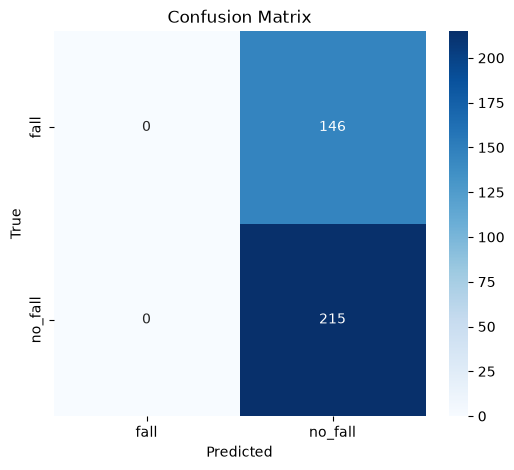


Classification Report:

              precision    recall  f1-score   support

        fall       0.00      0.00      0.00       146
     no_fall       0.60      1.00      0.75       215

    accuracy                           0.60       361
   macro avg       0.30      0.50      0.37       361
weighted avg       0.35      0.60      0.44       361



c:\Users\GArvit\Desktop\Fall Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\GArvit\Desktop\Fall Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\GArvit\Desktop\Fall Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [17]:
# Confusion matrix and classification report
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[inv_class_indices[i] for i in range(len(inv_class_indices))], yticklabels=[inv_class_indices[i] for i in range(len(inv_class_indices))])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
print('\nClassification Report:\n')
print(classification_report(y_true, y_pred, target_names=[inv_class_indices[i] for i in range(len(inv_class_indices))]))

In [ ]:
# Show some misclassified examples
filepaths = getattr(val_gen, 'filepaths', None)
if filepaths is None:
    # Keras may provide 'filenames' instead; construct full paths
    filepaths = [os.path.join(val_dir, f) for f in val_gen.filenames]
mis_idx = np.where(y_true != y_pred)[0]

print(f'Misclassified samples: {len(mis_idx)}')
n_show = min(12, len(mis_idx))
if n_show > 0:
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(mis_idx[:n_show]):
        img_path = filepaths[idx]
        try:
            img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
            ax = plt.subplot(3, 4, i+1)
            plt.imshow(img)
            true_label = inv_class_indices[y_true[idx]]
            pred_label = inv_class_indices[y_pred[idx]]
            plt.title(f'True: {true_label} | Pred: {pred_label}')
            plt.axis('off')
        except Exception as e:
            print('Could not load', img_path, e)
    plt.tight_layout()
    plt.show()
else:
    print('No misclassified examples to show.')

In [ ]:
# Save a CSV of predictions and errors for deeper analysis
results = pd.DataFrame({\n                    'filepath': filepaths,\n                    'true': [inv_class_indices[c] for c in y_true],\n                    'pred': [inv_class_indices[p] for p in y_pred]\n                })
results['correct'] = results['true'] == results['pred']
results.to_csv('results/validation_predictions.csv', index=False)
print('Wrote results/validation_predictions.csv')

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    mean_squared_error,
    log_loss
)

from sklearn.model_selection import train_test_split

In [2]:
PROJECT_ROOT = Path("..")

MODEL_PATH = PROJECT_ROOT / "models" / "tuned_resnet50.keras"

VAL_DIR = PROJECT_ROOT / "data" / "validation"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "error_analysis"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Model path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

print("Validation directory:", VAL_DIR)
print("Validation directory exists:", VAL_DIR.exists())

print("Output directory:", OUTPUT_DIR)

Model path: ..\models\tuned_resnet50.keras
Model exists: True
Validation directory: ..\data\validation
Validation directory exists: False
Output directory: ..\outputs\error_analysis


In [7]:
@tf.keras.utils.register_keras_serializable(package="FallDetection")
class ResNet50Preprocessing(tf.keras.layers.Layer):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return tf.keras.applications.resnet50.preprocess_input(
            inputs
        )

    def get_config(self):
        config = super().get_config()
        return config

In [8]:
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "ResNet50Preprocessing": ResNet50Preprocessing
    },
    compile=False
)

print("Model loaded successfully.")


Model loaded successfully.


In [11]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("TensorFlow class names:", val_ds.class_names)

Found 361 files belonging to 2 classes.


TensorFlow class names: ['fall', 'no_fall']


In [12]:
for index, class_name in enumerate(val_ds.class_names):
    print(index, "=", class_name)

0 = fall
1 = no_fall


In [13]:
dataset_labels = np.concatenate(
    [
        labels.numpy().reshape(-1)
        for images, labels in val_ds
    ]
).astype(int)

print("TensorFlow label counts:")
print(
    np.unique(
        dataset_labels,
        return_counts=True
    )
)

TensorFlow label counts:
(array([0, 1]), array([146, 215]))


In [28]:
# TensorFlow directory labels:
# 0 = Fall
# 1 = No Fall

dataset_labels = np.concatenate(
    [
        labels.numpy().reshape(-1)
        for images, labels in val_ds
    ]
).astype(int)

# Saved model output already represents P(Fall)
model_probabilities = model.predict(
    val_ds,
    verbose=1
).reshape(-1)

model_probabilities = np.clip(
    model_probabilities,
    1e-7,
    1 - 1e-7
)

# Convert labels to project convention:
# 0 = No Fall
# 1 = Fall
y_true = 1 - dataset_labels

# Do not invert probabilities.
# The saved model already outputs probability of Fall.
raw_probabilities = model_probabilities

23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 656ms/step


In [29]:
raw_predictions_full = (
    raw_probabilities >= 0.50
).astype(int)

print("Label counts:", np.unique(y_true, return_counts=True))

print(
    "Accuracy:",
    accuracy_score(y_true, raw_predictions_full)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_true, raw_probabilities)
)

print(
    classification_report(
        y_true,
        raw_predictions_full,
        target_names=["No Fall", "Fall"],
        zero_division=0
    )
)

Label counts: (array([0, 1]), array([215, 146]))
Accuracy: 0.9279778393351801
ROC-AUC: 0.9901242433896145
              precision    recall  f1-score   support

     No Fall       0.90      0.99      0.94       215
        Fall       0.98      0.84      0.90       146

    accuracy                           0.93       361
   macro avg       0.94      0.91      0.92       361
weighted avg       0.93      0.93      0.93       361



In [30]:
raw_predictions_full = (
    raw_probabilities >= 0.50
).astype(int)

print(
    classification_report(
        y_true,
        raw_predictions_full,
        target_names=["No Fall", "Fall"],
        zero_division=0
    )
)

print("Accuracy:", accuracy_score(y_true, raw_predictions_full))
print("ROC-AUC:", roc_auc_score(y_true, raw_probabilities))

              precision    recall  f1-score   support

     No Fall       0.90      0.99      0.94       215
        Fall       0.98      0.84      0.90       146

    accuracy                           0.93       361
   macro avg       0.94      0.91      0.92       361
weighted avg       0.93      0.93      0.93       361

Accuracy: 0.9279778393351801
ROC-AUC: 0.9901242433896145


In [31]:
(
    calibration_probs,
    evaluation_probs,
    calibration_labels,
    evaluation_labels
) = train_test_split(
    raw_probabilities,
    y_true,
    test_size=0.50,
    random_state=42,
    stratify=y_true
)

print("Calibration samples:", len(calibration_labels))
print("Evaluation samples:", len(evaluation_labels))

print(
    "Calibration counts:",
    np.unique(calibration_labels, return_counts=True)
)

print(
    "Evaluation counts:",
    np.unique(evaluation_labels, return_counts=True)
)

Calibration samples: 180
Evaluation samples: 181
Calibration counts: (array([0, 1]), array([107,  73]))
Evaluation counts: (array([0, 1]), array([108,  73]))


In [32]:
def probability_to_logit(probabilities):
    probabilities = np.asarray(
        probabilities
    ).reshape(-1)

    probabilities = np.clip(
        probabilities,
        1e-7,
        1 - 1e-7
    )

    return np.log(
        probabilities / (1 - probabilities)
    )

In [33]:
calibration_logits = probability_to_logit(
    calibration_probs
)

evaluation_logits = probability_to_logit(
    evaluation_probs
)

In [34]:
def apply_temperature(logits, temperature):
    if temperature <= 0:
        raise ValueError(
            "Temperature must be greater than zero."
        )

    scaled_logits = logits / temperature

    probabilities = 1 / (
        1 + np.exp(-scaled_logits)
    )

    return np.clip(
        probabilities,
        1e-7,
        1 - 1e-7
    )

In [35]:
temperature_values = np.arange(
    0.10,
    5.01,
    0.01
)

best_temperature = 1.0
best_calibration_loss = float("inf")

temperature_results = []

for temperature in temperature_values:
    calibrated_probs = apply_temperature(
        calibration_logits,
        temperature
    )

    current_loss = log_loss(
        calibration_labels,
        calibrated_probs
    )

    temperature_results.append({
        "Temperature": temperature,
        "Log_Loss": current_loss
    })

    if current_loss < best_calibration_loss:
        best_calibration_loss = current_loss
        best_temperature = temperature

print(f"Best temperature: {best_temperature:.2f}")
print(
    f"Best calibration log loss: "
    f"{best_calibration_loss:.4f}"
)

Best temperature: 1.06
Best calibration log loss: 0.2131


In [36]:
calibrated_evaluation_probs = apply_temperature(
    evaluation_logits,
    best_temperature
)

print("Before calibration:")
print(evaluation_probs[:10])

print("\nAfter calibration:")
print(calibrated_evaluation_probs[:10])

Before calibration:
[3.0714076e-04 8.8191468e-01 5.9105657e-02 9.6068595e-04 2.2742789e-02
 1.1906060e-03 8.5995090e-01 3.8333336e-01 8.6029488e-01 5.5548808e-05]

After calibration:
[4.85380571e-04 8.69537463e-01 6.84431954e-02 1.42283376e-03
 2.79866197e-02 1.74189356e-03 8.47115327e-01 3.89714404e-01
 8.47464327e-01 9.67214841e-05]


In [37]:
THRESHOLD = 0.50

raw_predictions = (
    evaluation_probs >= THRESHOLD
).astype(int)

calibrated_predictions = (
    calibrated_evaluation_probs >= THRESHOLD
).astype(int)

In [38]:
def calculate_metrics(
    true_labels,
    probabilities,
    threshold=0.50
):
    true_labels = np.asarray(
        true_labels
    ).reshape(-1).astype(int)

    probabilities = np.asarray(
        probabilities
    ).reshape(-1)

    probabilities = np.clip(
        probabilities,
        1e-7,
        1 - 1e-7
    )

    predictions = (
        probabilities >= threshold
    ).astype(int)

    rmse = np.sqrt(
        mean_squared_error(
            true_labels,
            probabilities
        )
    )

    return {
        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),
        "Precision": precision_score(
            true_labels,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            true_labels,
            predictions,
            zero_division=0
        ),
        "F1_Score": f1_score(
            true_labels,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            true_labels,
            probabilities
        ),
        "PR_AUC": average_precision_score(
            true_labels,
            probabilities
        ),
        "RMSE": rmse,
        "Log_Loss": log_loss(
            true_labels,
            probabilities
        )
    }

In [39]:
raw_metrics = calculate_metrics(
    evaluation_labels,
    evaluation_probs,
    threshold=THRESHOLD
)

calibrated_metrics = calculate_metrics(
    evaluation_labels,
    calibrated_evaluation_probs,
    threshold=THRESHOLD
)

In [40]:
comparison_df = pd.DataFrame([
    {
        "Model": "Before Temperature Scaling",
        **raw_metrics
    },
    {
        "Model": "After Temperature Scaling",
        **calibrated_metrics
    }
])

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,RMSE,Log_Loss
0,Before Temperature Scaling,0.9392,0.9844,0.863,0.9197,0.9902,0.9848,0.2275,0.1737
1,After Temperature Scaling,0.9392,0.9844,0.863,0.9197,0.9902,0.9848,0.2295,0.1768


In [41]:
print(
    classification_report(
        evaluation_labels,
        calibrated_predictions,
        target_names=["No Fall", "Fall"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     No Fall       0.91      0.99      0.95       108
        Fall       0.98      0.86      0.92        73

    accuracy                           0.94       181
   macro avg       0.95      0.93      0.94       181
weighted avg       0.94      0.94      0.94       181



In [42]:
cm = confusion_matrix(
    evaluation_labels,
    calibrated_predictions
)

print(cm)

tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

[[107   1]
 [ 10  63]]
True Negatives: 107
False Positives: 1
False Negatives: 10
True Positives: 63


In [43]:
error_df = pd.DataFrame({
    "Actual_Label": evaluation_labels,
    "Raw_Fall_Probability": evaluation_probs,
    "Calibrated_Fall_Probability":
        calibrated_evaluation_probs,
    "Predicted_Label": calibrated_predictions
})

In [44]:
label_names = {
    0: "No Fall",
    1: "Fall"
}

error_df["Actual_Class"] = (
    error_df["Actual_Label"]
    .map(label_names)
)

error_df["Predicted_Class"] = (
    error_df["Predicted_Label"]
    .map(label_names)
)

In [45]:
conditions = [
    (
        error_df["Actual_Label"] == 1
    ) & (
        error_df["Predicted_Label"] == 1
    ),

    (
        error_df["Actual_Label"] == 0
    ) & (
        error_df["Predicted_Label"] == 0
    ),

    (
        error_df["Actual_Label"] == 0
    ) & (
        error_df["Predicted_Label"] == 1
    ),

    (
        error_df["Actual_Label"] == 1
    ) & (
        error_df["Predicted_Label"] == 0
    )
]

categories = [
    "True Positive",
    "True Negative",
    "False Positive",
    "False Negative"
]

error_df["Prediction_Type"] = np.select(
    conditions,
    categories,
    default="Unknown"
)

error_df.head()

,Actual_Label,Raw_Fall_Probability,Calibrated_Fall_Probability,Predicted_Label,Actual_Class,Predicted_Class,Prediction_Type
0,0,0.000307,0.000485,0,No Fall,No Fall,True Negative
1,1,0.881915,0.869537,1,Fall,Fall,True Positive
2,0,0.059106,0.068443,0,No Fall,No Fall,True Negative
3,0,0.000961,0.001423,0,No Fall,No Fall,True Negative
4,0,0.022743,0.027987,0,No Fall,No Fall,True Negative


In [46]:
false_positives_df = error_df[
    error_df["Prediction_Type"]
    == "False Positive"
].copy()

false_positives_df = false_positives_df.sort_values(
    by="Calibrated_Fall_Probability",
    ascending=False
)

false_positives_df.head(10)

,Actual_Label,Raw_Fall_Probability,Calibrated_Fall_Probability,Predicted_Label,Actual_Class,Predicted_Class,Prediction_Type
172,0,0.735228,0.723822,1,No Fall,Fall,False Positive


In [49]:
false_negatives_df = error_df[
    error_df["Prediction_Type"]
    == "False Negative"
].copy()

false_negatives_df = false_negatives_df.sort_values(
    by="Calibrated_Fall_Probability",
    ascending=True
)

false_negatives_df.head(10)

,Actual_Label,Raw_Fall_Probability,Calibrated_Fall_Probability,Predicted_Label,Actual_Class,Predicted_Class,Prediction_Type
99,1,0.041568,0.049250,0,Fall,No Fall,False Negative
158,1,0.230834,0.243151,0,Fall,No Fall,False Negative
71,1,0.272774,0.283923,0,Fall,No Fall,False Negative
57,1,0.369262,0.376347,0,Fall,No Fall,False Negative
7,1,0.383333,0.389714,0,Fall,No Fall,False Negative
23,1,0.401424,0.406870,0,Fall,No Fall,False Negative
104,1,0.452287,0.454973,0,Fall,No Fall,False Negative
116,1,0.454488,0.457051,0,Fall,No Fall,False Negative
108,1,0.467126,0.468982,0,Fall,No Fall,False Negative
80,1,0.467376,0.469218,0,Fall,No Fall,False Negative


In [50]:
comparison_df.to_csv(
    OUTPUT_DIR / "temperature_rmse_comparison.csv",
    index=False
)

error_df.to_csv(
    OUTPUT_DIR / "prediction_error_analysis.csv",
    index=False
)

false_positives_df.to_csv(
    OUTPUT_DIR / "false_positives.csv",
    index=False
)

false_negatives_df.to_csv(
    OUTPUT_DIR / "false_negatives.csv",
    index=False
)

pd.DataFrame(
    temperature_results
).to_csv(
    OUTPUT_DIR / "temperature_search_results.csv",
    index=False
)

print("All results saved.")

All results saved.


In [51]:
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,RMSE,Log_Loss
0,Before Temperature Scaling,0.9392,0.9844,0.863,0.9197,0.9902,0.9848,0.2275,0.1737
1,After Temperature Scaling,0.9392,0.9844,0.863,0.9197,0.9902,0.9848,0.2295,0.1768


In [55]:
from sklearn.metrics import classification_report

print(
    classification_report(
        evaluation_labels,
        calibrated_predictions,
        target_names=["No Fall", "Fall"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     No Fall       0.91      0.99      0.95       108
        Fall       0.98      0.86      0.92        73

    accuracy                           0.94       181
   macro avg       0.95      0.93      0.94       181
weighted avg       0.94      0.94      0.94       181



In [57]:
print(
    classification_report(
        evaluation_labels,
        raw_predictions,
        target_names=["No Fall", "Fall"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     No Fall       0.91      0.99      0.95       108
        Fall       0.98      0.86      0.92        73

    accuracy                           0.94       181
   macro avg       0.95      0.93      0.94       181
weighted avg       0.94      0.94      0.94       181



In [58]:
print(evaluation_labels.shape)
print(raw_predictions.shape)
print(calibrated_predictions.shape)

(181,)
(181,)
(181,)


In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    evaluation_labels,
    calibrated_predictions
)

print(cm)

[[107   1]
 [ 10  63]]


In [60]:
print(
    classification_report(
        evaluation_labels,
        calibrated_predictions,
        target_names=["No Fall", "Fall"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     No Fall       0.91      0.99      0.95       108
        Fall       0.98      0.86      0.92        73

    accuracy                           0.94       181
   macro avg       0.95      0.93      0.94       181
weighted avg       0.94      0.94      0.94       181



In [61]:
print("False Positives:", len(false_positives_df))
print("False Negatives:", len(false_negatives_df))

False Positives: 1
False Negatives: 10


In [62]:
false_positives_df.head(5)
false_negatives_df.head(5)

,Actual_Label,Raw_Fall_Probability,Calibrated_Fall_Probability,Predicted_Label,Actual_Class,Predicted_Class,Prediction_Type
99,1,0.041568,0.049250,0,Fall,No Fall,False Negative
158,1,0.230834,0.243151,0,Fall,No Fall,False Negative
71,1,0.272774,0.283923,0,Fall,No Fall,False Negative
57,1,0.369262,0.376347,0,Fall,No Fall,False Negative
7,1,0.383333,0.389714,0,Fall,No Fall,False Negative


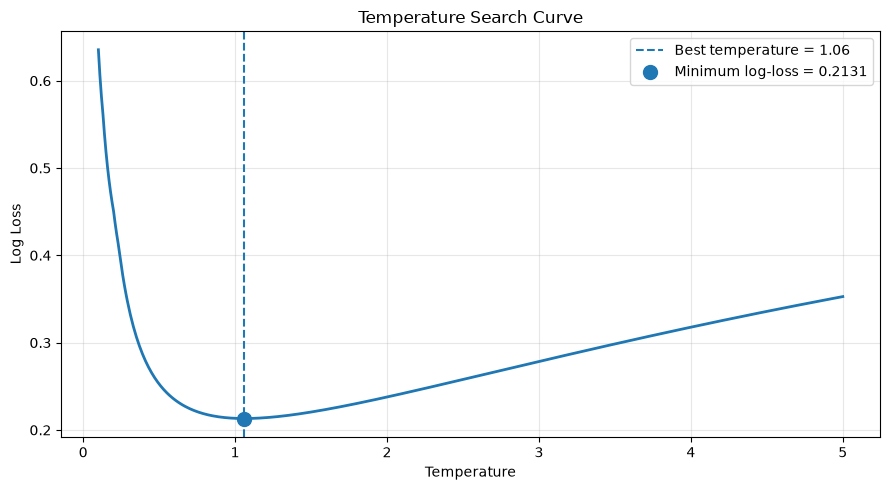

In [66]:
# Convert temperature search results into a DataFrame
temperature_df = pd.DataFrame(temperature_results)

plt.figure(figsize=(9, 5))

plt.plot(
    temperature_df["Temperature"],
    temperature_df["Log_Loss"],
    linewidth=2
)

# Mark the best temperature
plt.axvline(
    x=best_temperature,
    linestyle="--",
    label=f"Best temperature = {best_temperature:.2f}"
)

plt.scatter(
    best_temperature,
    best_calibration_loss,
    s=100,
    zorder=3,
    label=f"Minimum log-loss = {best_calibration_loss:.4f}"
)

plt.xlabel("Temperature")
plt.ylabel("Log Loss")
plt.title("Temperature Search Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "temperature_search_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

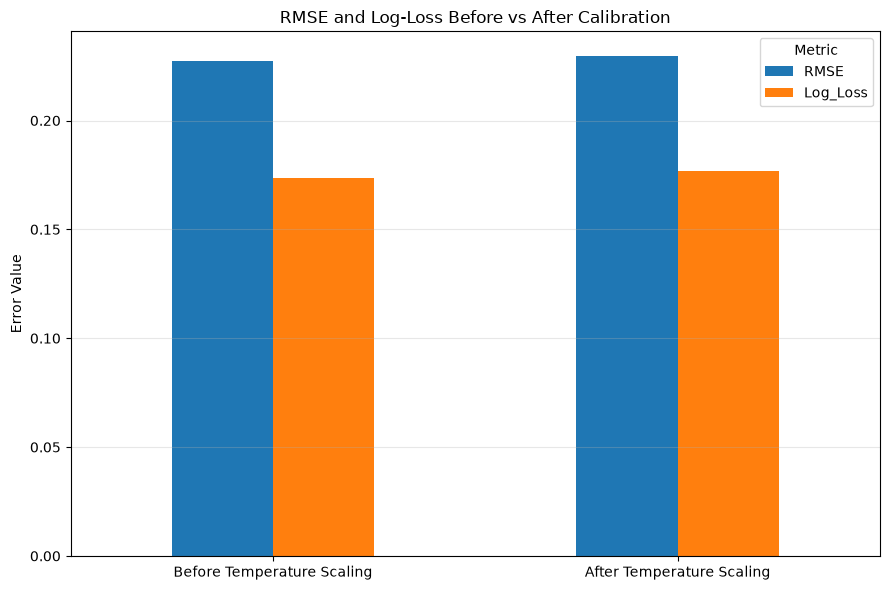

In [67]:
# Take only the calibration-error metrics
error_comparison = comparison_df[
    ["Model", "RMSE", "Log_Loss"]
].copy()

error_comparison = error_comparison.set_index("Model")

ax = error_comparison.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("RMSE and Log-Loss Before vs After Calibration")
plt.xlabel("")
plt.ylabel("Error Value")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "rmse_logloss_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

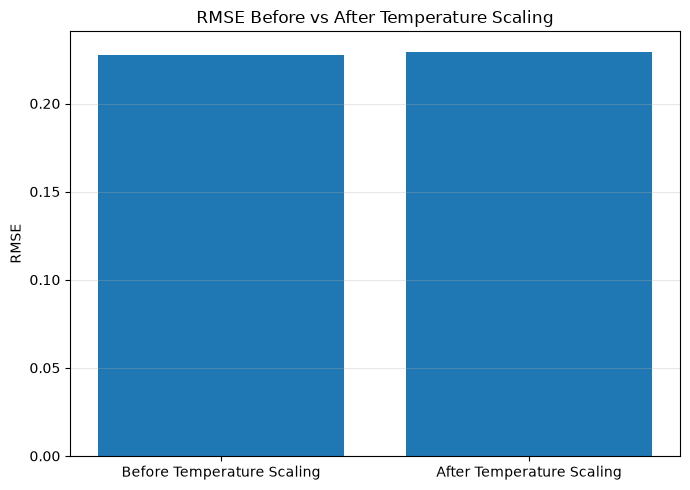

In [68]:
plt.figure(figsize=(7, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["RMSE"]
)

plt.title("RMSE Before vs After Temperature Scaling")
plt.xlabel("")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

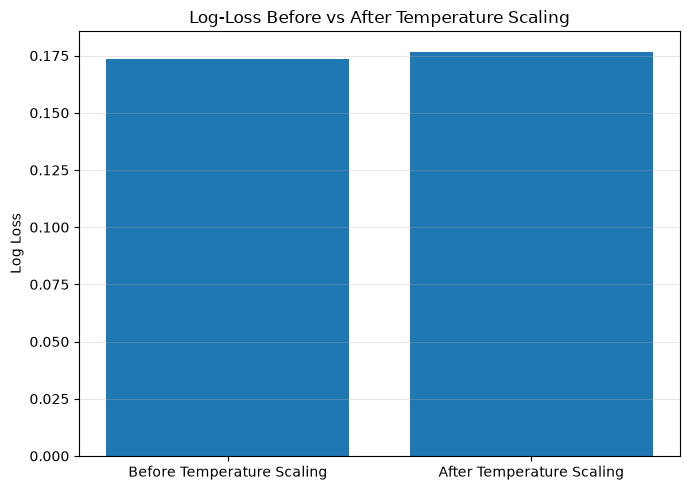

In [69]:
plt.figure(figsize=(7, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Log_Loss"]
)

plt.title("Log-Loss Before vs After Temperature Scaling")
plt.xlabel("")
plt.ylabel("Log Loss")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "logloss_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()